In [55]:
from langgraph.graph import START, END, StateGraph, add_messages
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.runnables import Runnable
from typing import Literal, Annotated
from collections.abc import Sequence

In [56]:
from dotenv import load_dotenv
load_dotenv()

True

In [57]:
my_list = add_messages([HumanMessage("Hii! I am ANIK."),
                                     AIMessage("Hey, Anik. How Can I Help You?")],
                                     [HumanMessage("Please Summarise recent news")])

my_list

[HumanMessage(content='Hii! I am ANIK.', additional_kwargs={}, response_metadata={}, id='dc5dedaf-582a-4093-9b21-0a44d09cd859'),
 AIMessage(content='Hey, Anik. How Can I Help You?', additional_kwargs={}, response_metadata={}, id='7c335dc6-6362-4cb2-a8d0-b18a2c8e5013', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please Summarise recent news', additional_kwargs={}, response_metadata={}, id='ab43c607-9666-4945-af0e-ce8a15062b56')]

In [58]:
class State(TypedDict):
    messages : Annotated[Sequence[BaseMessage], add_messages]

#add_message is a reducer function that defines how to combine the current state with the new incomming data in a structured way 

In [59]:
def ask(state=State)-> State:
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(input())])    

In [60]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [61]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

In [62]:
def ask_another(state=State)->State:
    print("\n --------------> Entering Ask Another State:")
    for i in state['messages']:
        i.pretty_print()
    question = "Any other question ? (Yes/No)"
    print(question)

    return State(messages=[AIMessage(content=question), HumanMessage(content=input().strip())])

In [63]:
def routing(state:State)-> Literal["ask", "__end__"]:
    if state["messages"][-1].content.lower() == "yes":
        return "ask"
    else:
        return "__end__"

In [64]:
graph = StateGraph(State)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)

In [65]:
graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)



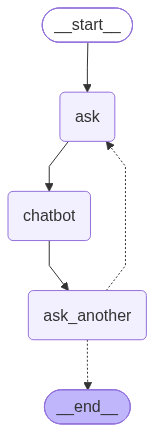

In [66]:
graph_complied = graph.compile()

graph_complied

In [67]:
graph_complied.invoke(State(messages=[]))


-------> Entering the ask state
What is your Question ?

--------------> Entering Chatbot:
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Identify the User's Question**: The user is asking "who is the PM of india" (Prime Minister of India).
2.  **Identify Key Entity**: Prime Minister of India.
3.  **Determine Current Information**: As of my last update (2024), the Prime Minister of India is Narendra Modi. He has been in office since May 2014 and was re-elected for a third term in June 2024.
4.  **Verify Accuracy**: I need to confirm that this information is still current. Since my knowledge cutoff is 2024, and Narendra Modi's third term began in June 2024, this is accurate. I should also note that political positions can change, so it's good practice to mention the timeframe or suggest verifying with up-to-date sources if needed, but for this straightforward factual question, a direct answer is appropriate.


{'messages': [AIMessage(content='What is your Question ?', additional_kwargs={}, response_metadata={}, id='0abd0811-35d0-4435-964a-947038d72dcf', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='who is the PM of india', additional_kwargs={}, response_metadata={}, id='5b18a47d-8f49-466a-94fb-1176e98c72fe'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Identify the User\'s Question**: The user is asking "who is the PM of india" (Prime Minister of India).\n2.  **Identify Key Entity**: Prime Minister of India.\n3.  **Determine Current Information**: As of my last update (2024), the Prime Minister of India is Narendra Modi. He has been in office since May 2014 and was re-elected for a third term in June 2024.\n4.  **Verify Accuracy**: I need to confirm that this information is still current. Since my knowledge cutoff is 2024, and Narendra Modi\'s third term began in June 2024, this is accurate. I should also note that political positions can change, so 